# 01 — LIF Neuron Tutorial

Interactive exploration of Leaky Integrate-and-Fire (LIF) neurons using snnTorch.

**Goals (Week 1 / Track A):**
- Understand the LIF membrane dynamics: `V[t+1] = β·V[t] + I[t]·(1 − s[t])`
- Observe how β (decay rate) controls spike patterns
- Build intuition for threshold, reset, and leakage behaviour

In [5]:
import torch
import snntorch as snn
import matplotlib.pyplot as plt
import numpy as np

print("snnTorch version:", snn.__version__)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

snnTorch version: 0.9.4
PyTorch version: 2.11.0+cpu
CUDA available: False


## 1. Single LIF neuron with constant input current

Create one `snn.Leaky` neuron, inject a fixed current, and record the
membrane voltage and spike train over 200 timesteps.

In [6]:
num_steps = 200
beta = 0.9
input_current = 0.3  # constant drive

lif = snn.Leaky(beta=beta)
mem = lif.init_leaky()

mem_rec = []
spk_rec = []

for step in range(num_steps):
    cur = torch.tensor([input_current])
    spk, mem = lif(cur, mem)
    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

mem_rec = np.array(mem_rec)
spk_rec = np.array(spk_rec)

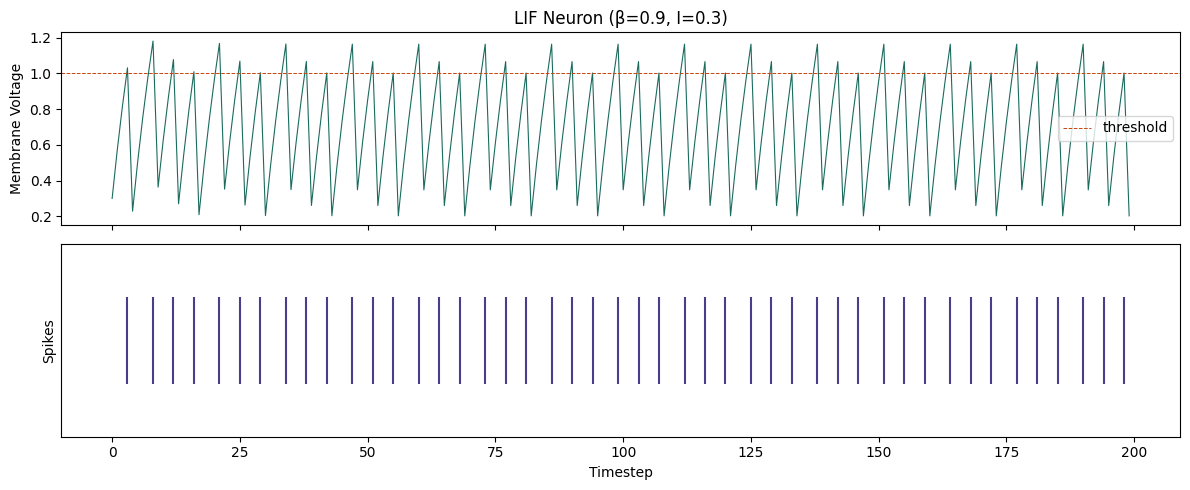

Total spikes fired: 46


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(mem_rec, color="#1a6b5e", linewidth=0.8)
axes[0].axhline(1.0, color="#c8440a", linestyle="--", linewidth=0.7, label="threshold")
axes[0].set_ylabel("Membrane Voltage")
axes[0].legend()
axes[0].set_title(f"LIF Neuron (β={beta}, I={input_current})")

spike_times = np.where(spk_rec > 0)[0]
axes[1].eventplot(spike_times, lineoffsets=0.5, colors="#4a3d8c")
axes[1].set_ylabel("Spikes")
axes[1].set_xlabel("Timestep")
axes[1].set_yticks([])

plt.tight_layout()
plt.show()
print(f"Total spikes fired: {int(spk_rec.sum())}")

## 2. Sweeping β — how decay rate changes spike patterns

Lower β means faster leak (more voltage lost per step) → higher threshold
to reach → fewer, more spread-out spikes. Higher β retains more voltage →
fires more frequently.

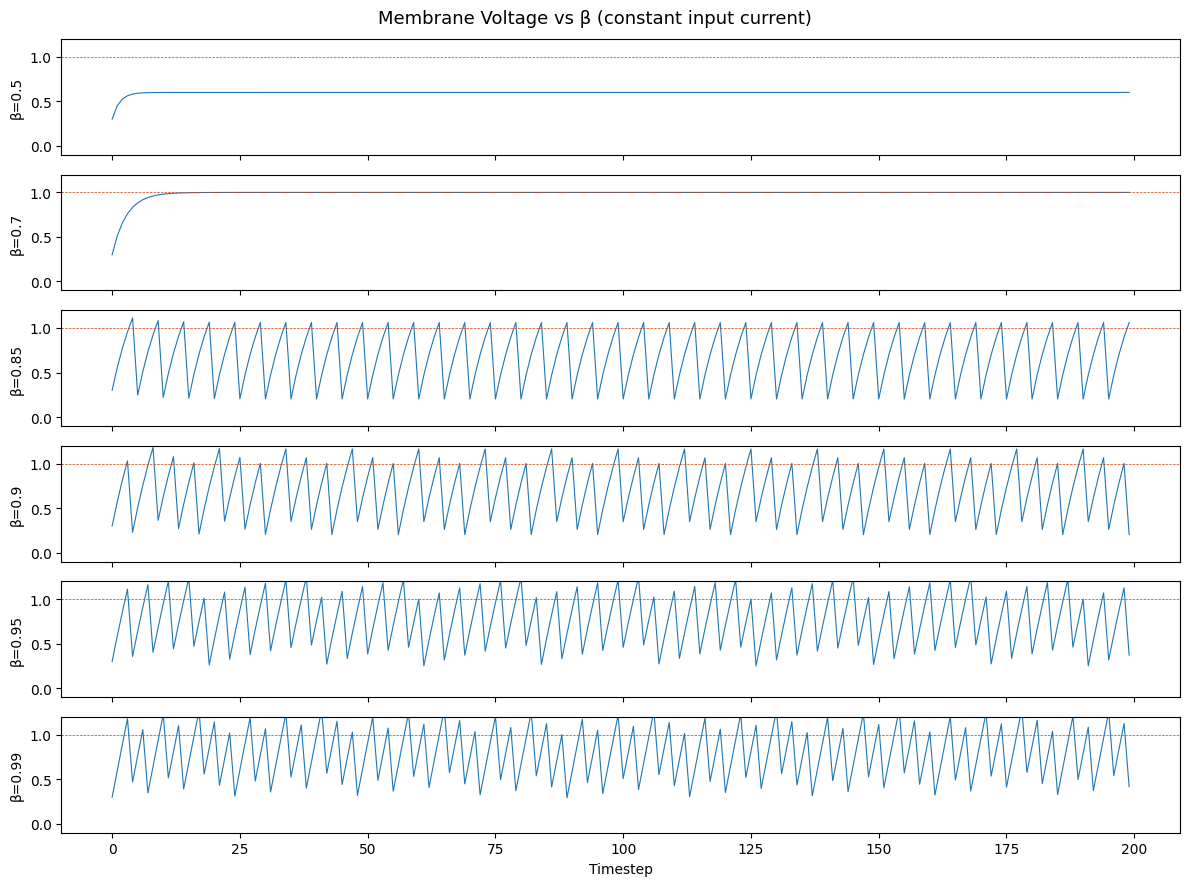

In [8]:
betas = [0.5, 0.7, 0.85, 0.9, 0.95, 0.99]
num_steps = 200
input_current = 0.3

fig, axes = plt.subplots(len(betas), 1, figsize=(12, 1.5 * len(betas)), sharex=True)

for i, beta_val in enumerate(betas):
    lif = snn.Leaky(beta=beta_val)
    mem = lif.init_leaky()
    mem_trace = []

    for _ in range(num_steps):
        cur = torch.tensor([input_current])
        spk, mem = lif(cur, mem)
        mem_trace.append(mem.item())

    axes[i].plot(mem_trace, linewidth=0.8)
    axes[i].axhline(1.0, color="#c8440a", linestyle="--", linewidth=0.5)
    axes[i].set_ylabel(f"β={beta_val}")
    axes[i].set_ylim(-0.1, 1.2)

axes[-1].set_xlabel("Timestep")
fig.suptitle("Membrane Voltage vs β (constant input current)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Spike count vs β

Quantify the relationship: count total spikes for each β value.

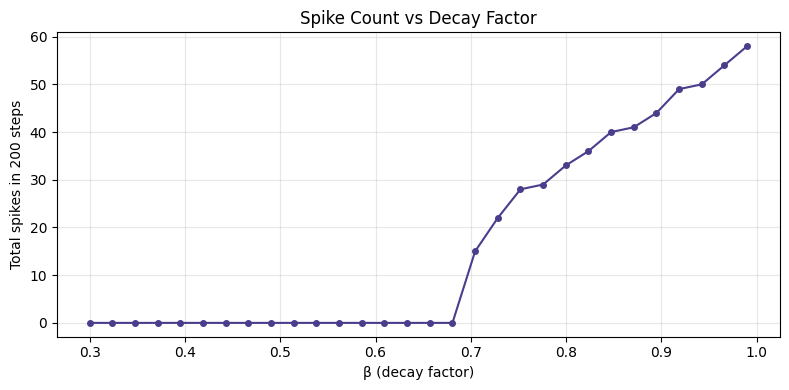

In [9]:
betas_fine = np.linspace(0.3, 0.99, 30)
spike_counts = []

for beta_val in betas_fine:
    lif = snn.Leaky(beta=float(beta_val))
    mem = lif.init_leaky()
    count = 0
    for _ in range(num_steps):
        cur = torch.tensor([input_current])
        spk, mem = lif(cur, mem)
        count += spk.item()
    spike_counts.append(count)

plt.figure(figsize=(8, 4))
plt.plot(betas_fine, spike_counts, "o-", color="#4a3d8c", markersize=4)
plt.xlabel("β (decay factor)")
plt.ylabel(f"Total spikes in {num_steps} steps")
plt.title("Spike Count vs Decay Factor")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Time-varying input current

Simulate a more realistic scenario where the input current changes over
time (e.g. a sinusoidal drive mimicking sensor readings).

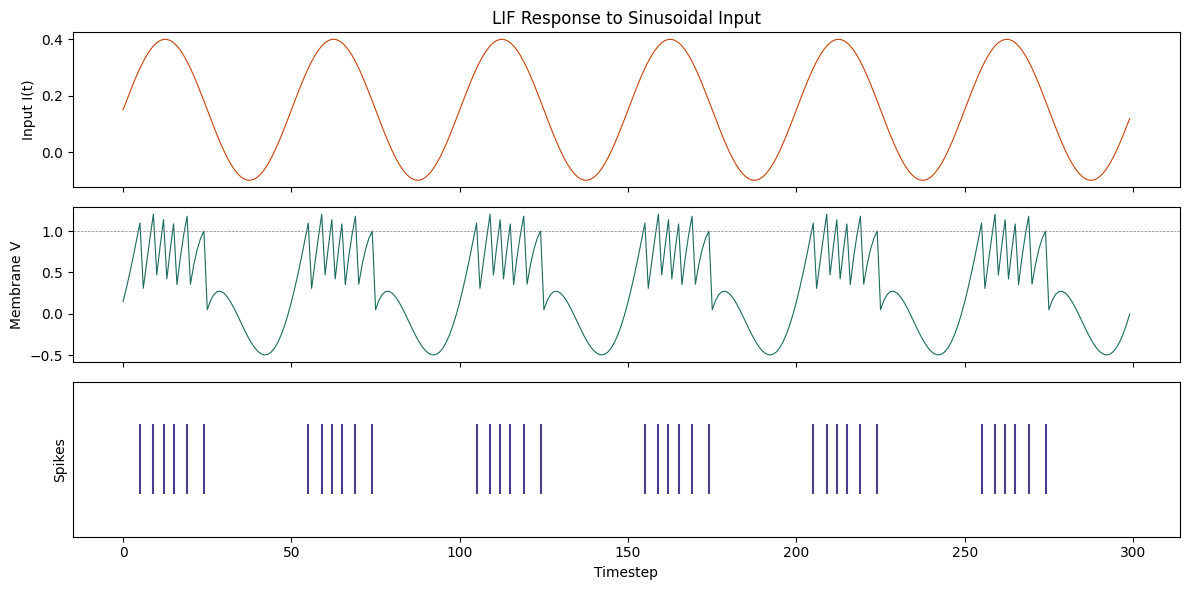

In [10]:
num_steps = 300
beta = 0.9
t = np.arange(num_steps)
current_signal = 0.25 * np.sin(2 * np.pi * t / 50) + 0.15

lif = snn.Leaky(beta=beta)
mem = lif.init_leaky()
mem_rec, spk_rec = [], []

for step in range(num_steps):
    cur = torch.tensor([current_signal[step]], dtype=torch.float32)
    spk, mem = lif(cur, mem)
    mem_rec.append(mem.item())
    spk_rec.append(spk.item())

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(current_signal, color="#c8440a", linewidth=0.8)
axes[0].set_ylabel("Input I(t)")
axes[0].set_title("LIF Response to Sinusoidal Input")

axes[1].plot(mem_rec, color="#1a6b5e", linewidth=0.8)
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=0.5)
axes[1].set_ylabel("Membrane V")

spike_times = np.where(np.array(spk_rec) > 0)[0]
axes[2].eventplot(spike_times, lineoffsets=0.5, colors="#4a3d8c")
axes[2].set_ylabel("Spikes")
axes[2].set_xlabel("Timestep")
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

## Key Takeaways

1. **β controls responsiveness**: High β (close to 1) → slow leak → neuron integrates over longer history → fires more. Low β → fast leak → only strong/sustained inputs cause spikes.
2. **Spike sparsity is the energy advantage**: Most timesteps produce no spike. Each spike is a single binary event, not a floating-point multiply.
3. **Threshold crossing is non-differentiable**: This is why surrogate gradients (FastSigmoid) are needed for training. The spike is approximated as a smooth function during backprop.

Next: `02_mnist_sanity.ipynb` — validate the full training pipeline on MNIST.